# Notebook 3 — Baseline Logistic Regression

| Trường | Nội dung |
|---|---|
| **Dự án** | Bayesian Uncertainty-Aware Financial Risk Forecasting |
| **Notebook** | 3 of 7 |
| **Input** | `data/processed/sp500_features.csv` |
| **Output** | `models/scaler.pkl` · `models/logistic_baseline.pkl` · `models/baseline_predictions.csv` · figures `reports/figures/nb3/` |
| **Trọng tâm** | Chronological Split · StandardScaler · Logistic Regression · Threshold Optimization (F2) |

## 1. Import & Cấu hình

In [57]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score, brier_score_loss,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

FIGURES_DIR = '../reports/figures/nb3'
MODELS_DIR  = '../models'
RESULTS_DIR = '../results/baseline'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('✓ Imports OK')

✓ Imports OK


## 2. Load dữ liệu & Định nghĩa features

In [58]:
df = pd.read_csv('../data/processed/sp500_features.csv', index_col=0, parse_dates=True)


FEATURE_COLS = ['Return', 'Volatility', 'MA_Ratio', 'Lag1', 'Lag2',
                'Intraday_Range', 'Close_Position',
                'Volume_Ratio', 'Volatility_Ratio']
TARGET = 'Label' 

X = df[FEATURE_COLS].values
y = df[TARGET].values

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Class balance: {y.mean():.3f} positive  ({y.sum()} / {len(y)})')

X shape : (2387, 9)
y shape : (2387,)
Class balance: 0.199 positive  (474 / 2387)


## 3. Chronological Split (60 / 20 / 20)

Dữ liệu tài chính là time-series → **không shuffle**. Split theo thứ tự thời gian để tránh look-ahead bias.

Tỷ lệ 60/20/20 đồng bộ với Notebook 4–7 để so sánh fair giữa LR và Bayesian LR.

In [59]:
print(df.index)
print(type(df.index[0]))

DatetimeIndex(['2015-07-07', '2015-07-08', '2015-07-09', '2015-07-10',
               '2015-07-13', '2015-07-14', '2015-07-15', '2015-07-16',
               '2015-07-17', '2015-07-20',
               ...
               '2024-12-13', '2024-12-16', '2024-12-17', '2024-12-18',
               '2024-12-19', '2024-12-20', '2024-12-23', '2024-12-24',
               '2024-12-26', '2024-12-27'],
              dtype='datetime64[us]', name='Date', length=2387, freq=None)
<class 'pandas.Timestamp'>


In [60]:
n = len(df)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

print("=== Chronological Split (60/20/20) ===")
print(f"Train : {X_train.shape} | rows 0 → {train_end-1}")
print(f"Val   : {X_val.shape} | rows {train_end} → {val_end-1}")
print(f"Test  : {X_test.shape} | rows {val_end} → {n-1}")

=== Chronological Split (60/20/20) ===
Train : (1432, 9) | rows 0 → 1431
Val   : (477, 9) | rows 1432 → 1908
Test  : (478, 9) | rows 1909 → 2386


In [61]:
n         = len(df)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = X[:train_end];  y_train = y[:train_end]
X_val   = X[train_end:val_end];  y_val   = y[train_end:val_end]
X_test  = X[val_end:];   y_test  = y[val_end:]

dates_train = df.index[:train_end]
dates_val   = df.index[train_end:val_end]
dates_test  = df.index[val_end:]

print('=== Chronological Split (60/20/20) ===')

print(f'  Train : {X_train.shape}  | {dates_train[0].date()} → {dates_train[-1].date()}')
print(f'  Val   : {X_val.shape}    | {dates_val[0].date()} → {dates_val[-1].date()}')
print(f'  Test  : {X_test.shape}   | {dates_test[0].date()} → {dates_test[-1].date()}')

=== Chronological Split (60/20/20) ===
  Train : (1432, 9)  | 2015-07-07 → 2021-03-12
  Val   : (477, 9)    | 2021-03-15 → 2023-02-02
  Test  : (478, 9)   | 2023-02-03 → 2024-12-27


## 4. StandardScaler — fit chỉ trên Train set

In [62]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform
X_val_s   = scaler.transform(X_val)          # chỉ transform
X_test_s  = scaler.transform(X_test)         # chỉ transform

joblib.dump(scaler, f'{MODELS_DIR}/scaler.pkl')
print(f'✓ Saved → {MODELS_DIR}/scaler.pkl')
print(f'  Scaler mean (first 3): {scaler.mean_[:3].round(6)}')
print(f'  Scaler std  (first 3): {scaler.scale_[:3].round(6)}')

✓ Saved → ../models/scaler.pkl
  Scaler mean (first 3): [4.500000e-04 9.042000e-03 1.004346e+00]
  Scaler std  (first 3): [0.012069 0.008197 0.02223 ]


## 5. Logistic Regression

$$P(y=1 \mid x, \theta) = \sigma(\theta^\top x) = \frac{1}{1 + \exp(-\theta^\top x)}$$

`class_weight='balanced'` để bù đắp mất cân bằng lớp (~25% positive).

In [63]:
model = LogisticRegression(max_iter=5000, class_weight='balanced', solver='lbfgs')
model.fit(X_train_s, y_train)

joblib.dump(model, f'{MODELS_DIR}/logistic_baseline.pkl')
print(f'✓ Saved → {MODELS_DIR}/logistic_baseline.pkl')
print()
print('Coefficients (θ):')
for feat, coef in zip(FEATURE_COLS, model.coef_[0]):
    print(f'  {feat:<22}: {coef:+.4f}')
print(f'  intercept             : {model.intercept_[0]:+.4f}')

✓ Saved → ../models/logistic_baseline.pkl

Coefficients (θ):
  Return                : -0.0414
  Volatility            : -0.0415
  MA_Ratio              : -0.6239
  Lag1                  : -0.2870
  Lag2                  : -0.1203
  Intraday_Range        : +0.3658
  Close_Position        : -0.1867
  Volume_Ratio          : +0.0657
  Volatility_Ratio      : +0.1640
  intercept             : -0.1765


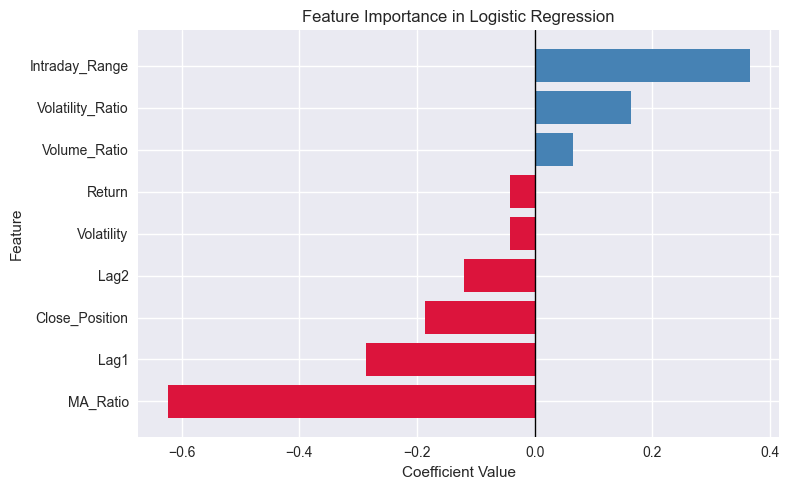

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': model.coef_[0]
})

coef_df = coef_df.sort_values('Coefficient')

plt.figure(figsize=(8,5))

colors = ['crimson' if x < 0 else 'steelblue'
          for x in coef_df['Coefficient']]

plt.barh(
    coef_df['Feature'],
    coef_df['Coefficient'],
    color=colors
)

plt.axvline(0, color='black', lw=1)

plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance in Logistic Regression')

plt.tight_layout()
plt.show()

## 6. Threshold Optimization trên Validation Set

Tối ưu ngưỡng quyết định theo **F2 Score** ($\beta = 2$) trên validation set.

### Tại sao F2 thay vì F1?

**F1** coi Precision và Recall có trọng số bằng nhau:

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**F2** cho Recall trọng số **gấp đôi** Precision ($\beta = 2$):

$$F_2 = \frac{(1 + \beta^2) \cdot \text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}} = \frac{5 \cdot \text{Precision} \cdot \text{Recall}}{4 \cdot \text{Precision} + \text{Recall}}$$

**Lý do chọn F2 trong bài toán tài chính:**

- **Miss một biến động mạnh (False Negative)** → bỏ lỡ tín hiệu rủi ro, hậu quả nghiêm trọng hơn.
- **Cảnh báo nhầm (False Positive)** → chỉ tốn chi phí giao dịch, ít nguy hiểm hơn.
- F2 phù hợp hơn F1 trong các bài toán phát hiện bất thường (anomaly detection) và quản lý rủi ro.

In [65]:
y_val_prob = model.predict_proba(X_val_s)[:, 1]

thresholds     = np.arange(0.10, 0.91, 0.01)
f2_scores      = []
f1_scores      = []
precision_list = []
recall_list    = []

for t in thresholds:
    y_pred_t = (y_val_prob >= t).astype(int)
    f2_scores.append(fbeta_score(y_val, y_pred_t, beta=2, zero_division=0))
    f1_scores.append(f1_score(y_val, y_pred_t, zero_division=0))
    precision_list.append(precision_score(y_val, y_pred_t, zero_division=0))
    recall_list.append(recall_score(y_val, y_pred_t, zero_division=0))

best_idx       = int(np.argmax(f2_scores))
BEST_THRESHOLD = float(thresholds[best_idx])
best_f2        = float(f2_scores[best_idx])
best_f1        = float(f1_scores[best_idx])

print(f'Best threshold (val) : {BEST_THRESHOLD:.2f}')
print(f'Best F2   (val)      : {best_f2:.4f}  ← optimized metric')
print(f'Best F1   (val)      : {best_f1:.4f}  (tham khảo)')
print(f'Precision (val)      : {precision_list[best_idx]:.4f}')
print(f'Recall    (val)      : {recall_list[best_idx]:.4f}')

Best threshold (val) : 0.40
Best F2   (val)      : 0.6241  ← optimized metric
Best F1   (val)      : 0.4467  (tham khảo)
Precision (val)      : 0.3030
Recall    (val)      : 0.8491


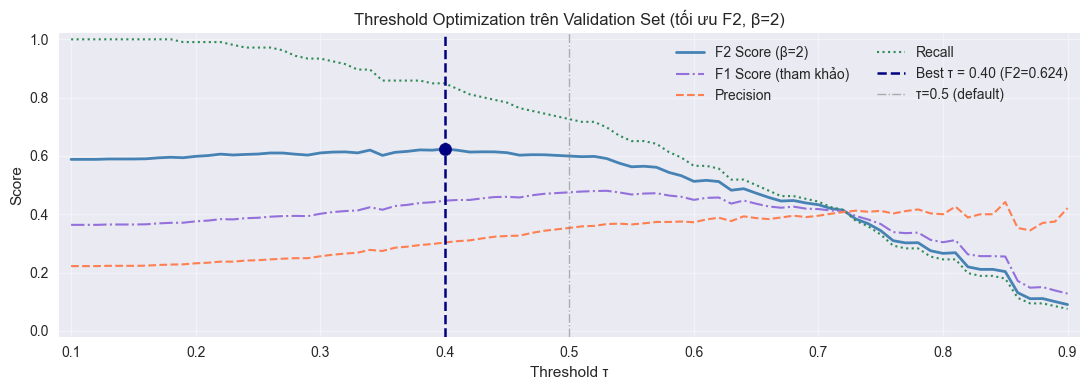

Saved → ../reports/figures/nb3/threshold_search.png


In [66]:
# ── Visualization 1: Threshold Search ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(thresholds, f2_scores,      color='steelblue', lw=2,   label='F2 Score (β=2)')
ax.plot(thresholds, f1_scores,      color='mediumpurple', lw=1.5, linestyle='-.',  label='F1 Score (tham khảo)')
ax.plot(thresholds, precision_list, color='coral',     lw=1.5, linestyle='--', label='Precision')
ax.plot(thresholds, recall_list,    color='seagreen',  lw=1.5, linestyle=':',  label='Recall')
ax.axvline(BEST_THRESHOLD, color='navy', lw=1.8, linestyle='--',
           label=f'Best τ = {BEST_THRESHOLD:.2f} (F2={best_f2:.3f})')
ax.axvline(0.5, color='gray', lw=1, linestyle='-.', alpha=0.6, label='τ=0.5 (default)')
ax.scatter([BEST_THRESHOLD], [best_f2], color='navy', s=80, zorder=5)

ax.set_title('Threshold Optimization trên Validation Set (tối ưu F2, β=2)', fontsize=12)
ax.set_xlabel('Threshold τ')
ax.set_ylabel('Score')
ax.set_xlim(0.09, 0.91)
ax.set_ylim(-0.02, 1.02)
ax.legend(ncol=2)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/threshold_search.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/threshold_search.png')

## 7. Đánh giá trên Test Set

In [67]:
y_test_prob = model.predict_proba(X_test_s)[:, 1]
y_test_pred = (y_test_prob >= BEST_THRESHOLD).astype(int)

# Metrics
acc_lr   = accuracy_score(y_test, y_test_pred)
prec_lr  = precision_score(y_test, y_test_pred, zero_division=0)
rec_lr   = recall_score(y_test, y_test_pred, zero_division=0)
f1_lr    = f1_score(y_test, y_test_pred, zero_division=0)
f2_lr    = fbeta_score(y_test, y_test_pred, beta=2, zero_division=0)
auc_lr   = roc_auc_score(y_test, y_test_prob)
brier_lr = brier_score_loss(y_test, y_test_prob)

# AUPRC
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_test_prob)
auprc_lr = auc(rec_curve, prec_curve)

print('=== Logistic Regression — Test Set Performance ===')
print(f'  Threshold  : {BEST_THRESHOLD:.2f} (optimized on val, metric=F2)')
print(f'  Accuracy   : {acc_lr:.4f}')
print(f'  Precision  : {prec_lr:.4f}')
print(f'  Recall     : {rec_lr:.4f}')
print(f'  F1 Score   : {f1_lr:.4f}')
print(f'  F2 Score   : {f2_lr:.4f}  ← optimized metric (β=2)')
print(f'  ROC-AUC    : {auc_lr:.4f}')
print(f'  AUPRC      : {auprc_lr:.4f}')
print(f'  Brier Score: {brier_lr:.4f}  (lower is better)')
print()
print('Classification Report:')
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Strong Movement']))

=== Logistic Regression — Test Set Performance ===
  Threshold  : 0.40 (optimized on val, metric=F2)
  Accuracy   : 0.6297
  Precision  : 0.2791
  Recall     : 0.7317
  F1 Score   : 0.4040
  F2 Score   : 0.5525  ← optimized metric (β=2)
  ROC-AUC    : 0.6870
  AUPRC      : 0.2886
  Brier Score: 0.1982  (lower is better)

Classification Report:
                 precision    recall  f1-score   support

         Normal       0.92      0.61      0.73       396
Strong Movement       0.28      0.73      0.40        82

       accuracy                           0.63       478
      macro avg       0.60      0.67      0.57       478
   weighted avg       0.81      0.63      0.68       478



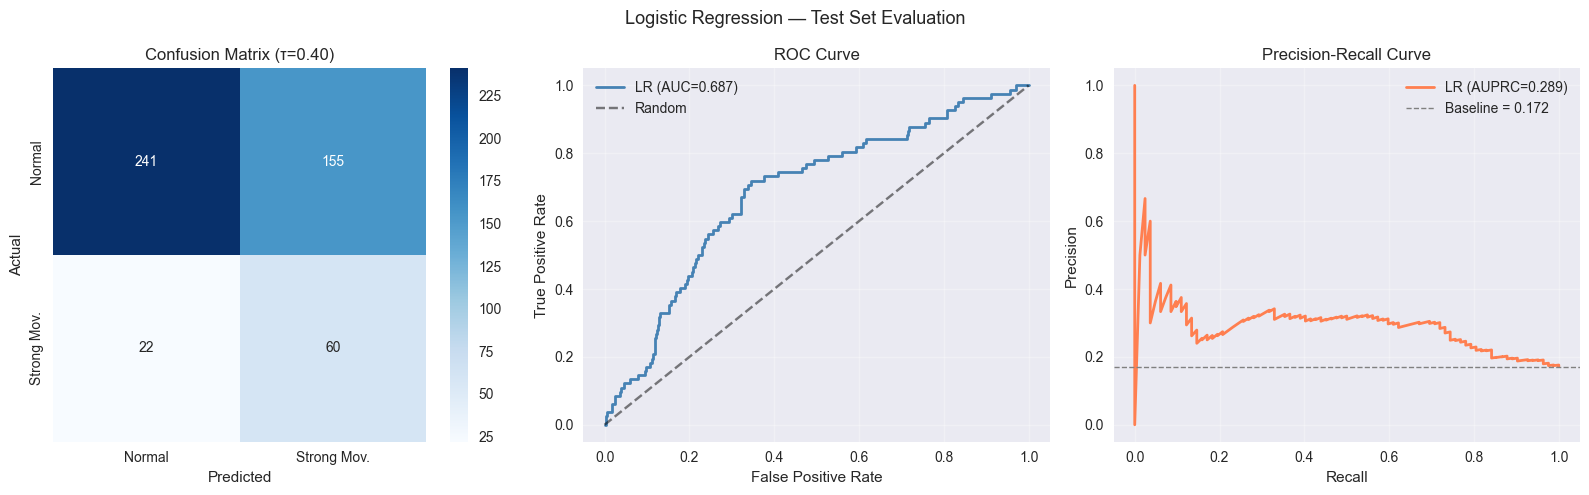

Saved → ../reports/figures/nb3/evaluation_curves.png


In [68]:
# ── Visualization 2: Confusion Matrix + ROC + PR Curve ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Logistic Regression — Test Set Evaluation', fontsize=13)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Strong Mov.'],
            yticklabels=['Normal', 'Strong Mov.'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix (τ={BEST_THRESHOLD:.2f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'LR (AUC={auc_lr:.3f})')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Random')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

# PR Curve
axes[2].plot(rec_curve, prec_curve, color='coral', lw=2,
             label=f'LR (AUPRC={auprc_lr:.3f})')
axes[2].axhline(y_test.mean(), color='gray', lw=1, linestyle='--',
                label=f'Baseline = {y_test.mean():.3f}')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/evaluation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/evaluation_curves.png')

## 8. Lưu predictions & metrics

In [69]:
# ── Lưu predictions CSV ────────────────────────────────────────────────────
baseline_preds = pd.DataFrame({
    'Actual'     : y_test,
    'Prediction' : y_test_pred,
    'Probability': y_test_prob
}, index=dates_test)
baseline_preds.index.name = 'Date'

baseline_preds.to_csv(f'{MODELS_DIR}/baseline_predictions.csv')
print(f'✓ Saved → {MODELS_DIR}/baseline_predictions.csv')

# ── Lưu metrics JSON ────────────────────────────────────────────────────────
lr_metrics = {
    'model'             : 'Logistic Regression',
    'split'             : '60/20/20 chronological',
    'threshold'         : round(BEST_THRESHOLD, 4),
    'threshold_metric'  : 'F2 (beta=2)',
    'accuracy'          : round(acc_lr,   4),
    'precision'         : round(prec_lr,  4),
    'recall'            : round(rec_lr,   4),
    'f1_score'          : round(f1_lr,    4),
    'f2_score'          : round(f2_lr,    4),
    'roc_auc'           : round(auc_lr,   4),
    'auprc'             : round(auprc_lr, 4),
    'brier_score'       : round(brier_lr, 4),
    'n_train'           : int(len(y_train)),
    'n_val'             : int(len(y_val)),
    'n_test'            : int(len(y_test)),
    'class_balance_test': round(float(y_test.mean()), 4)
}

metrics_path = f'{RESULTS_DIR}/lr_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(lr_metrics, f, indent=4)

print(f'✓ Saved → {metrics_path}')
print(json.dumps(lr_metrics, indent=4))

✓ Saved → ../models/baseline_predictions.csv
✓ Saved → ../results/baseline/lr_metrics.json
{
    "model": "Logistic Regression",
    "split": "60/20/20 chronological",
    "threshold": 0.4,
    "threshold_metric": "F2 (beta=2)",
    "accuracy": 0.6297,
    "precision": 0.2791,
    "recall": 0.7317,
    "f1_score": 0.404,
    "f2_score": 0.5525,
    "roc_auc": 0.687,
    "auprc": 0.2886,
    "brier_score": 0.1982,
    "n_train": 1432,
    "n_val": 477,
    "n_test": 478,
    "class_balance_test": 0.1715
}


In [70]:
# ============================================================================
# WALK-FORWARD + THRESHOLD TUNING
# Train % -> Predict next 20%
# ============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    precision_recall_curve
)

results = []

n = len(X)

train_ratios = [0.60, 0.65, 0.70, 0.75, 0.80]

for train_ratio in train_ratios:

    train_end = int(n * train_ratio)

    # next 20%
    test_end = min(
        train_end + int(n * 0.20),
        n
    )

    X_train_full = X[:train_end]
    y_train_full = y[:train_end]

    X_test = X[train_end:test_end]
    y_test = y[train_end:test_end]

    test_dates = df.index[train_end:test_end]

    if len(X_test) < 30:
        continue

    # =====================================================
    # INNER TRAIN / VALIDATION SPLIT
    # Last 20% of train used as validation
    # =====================================================

    inner_split = int(len(X_train_full) * 0.80)

    X_train = X_train_full[:inner_split]
    y_train = y_train_full[:inner_split]

    X_val = X_train_full[inner_split:]
    y_val = y_train_full[inner_split:]

    # =====================================================
    # Scaling
    # =====================================================

    scaler = StandardScaler()

    X_train_s = scaler.fit_transform(X_train)

    X_val_s = scaler.transform(X_val)

    X_test_s = scaler.transform(X_test)

    # =====================================================
    # Logistic Regression
    # =====================================================

    model = LogisticRegression(
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train_s, y_train)

    # =====================================================
    # THRESHOLD TUNING ON VALIDATION (F2, beta=2)
    # =====================================================

    val_prob = model.predict_proba(X_val_s)[:, 1]

    precision, recall, thresholds = precision_recall_curve(
        y_val,
        val_prob
    )

    # F2: trọng số recall gấp đôi precision
    f2_scores_wf = (
        5 * precision * recall
        / (4 * precision + recall + 1e-10)
    )

    best_idx = np.argmax(f2_scores_wf[:-1])

    best_threshold = thresholds[best_idx]

    best_val_f2 = f2_scores_wf[best_idx]

    # =====================================================
    # FINAL TEST EVALUATION
    # =====================================================

    y_prob = model.predict_proba(X_test_s)[:, 1]

    y_pred = (
        y_prob >= best_threshold
    ).astype(int)

    results.append({

        'Train_%':
            int(train_ratio * 100),

        'Train_End':
            str(df.index[train_end-1].date()),

        'Test_Start':
            str(test_dates[0].date()),

        'Test_End':
            str(test_dates[-1].date()),

        'Best_Threshold':
            round(float(best_threshold), 4),

        'Val_F2':
            round(float(best_val_f2), 4),

        'Accuracy':
            accuracy_score(y_test, y_pred),

        'Precision':
            precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        'Recall':
            recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        'F1':
            f1_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        'F2':
            fbeta_score(
                y_test,
                y_pred,
                beta=2,
                zero_division=0
            ),

        'ROC_AUC':
            roc_auc_score(
                y_test,
                y_prob
            )
    })

# ============================================================================
# RESULTS
# ============================================================================

wf_results = pd.DataFrame(results)

display(
    wf_results.round(4)
)

,Train_%,Train_End,Test_Start,Test_End,Best_Threshold,Val_F2,Accuracy,Precision,Recall,F1,F2,ROC_AUC
0,60,2021-03-12,2021-03-15,2023-02-02,0.3636,0.6404,0.4969,0.2880,0.8585,0.4313,0.6149,0.7070
1,65,2021-08-31,2021-09-01,2023-07-26,0.4738,0.4444,0.5870,0.3205,0.7981,0.4573,0.6148,0.7048
2,70,2022-02-18,2022-02-22,2024-01-16,0.4659,0.6443,0.5660,0.2591,0.7273,0.3821,0.5342,0.6728
3,75,2022-08-12,2022-08-15,2024-07-09,0.4042,0.6679,0.5660,0.2273,0.7333,0.3470,0.5074,0.6419
4,80,2023-02-02,2023-02-03,2024-12-26,0.3313,0.6454,0.4927,0.2279,0.8171,0.3564,0.5386,0.6923


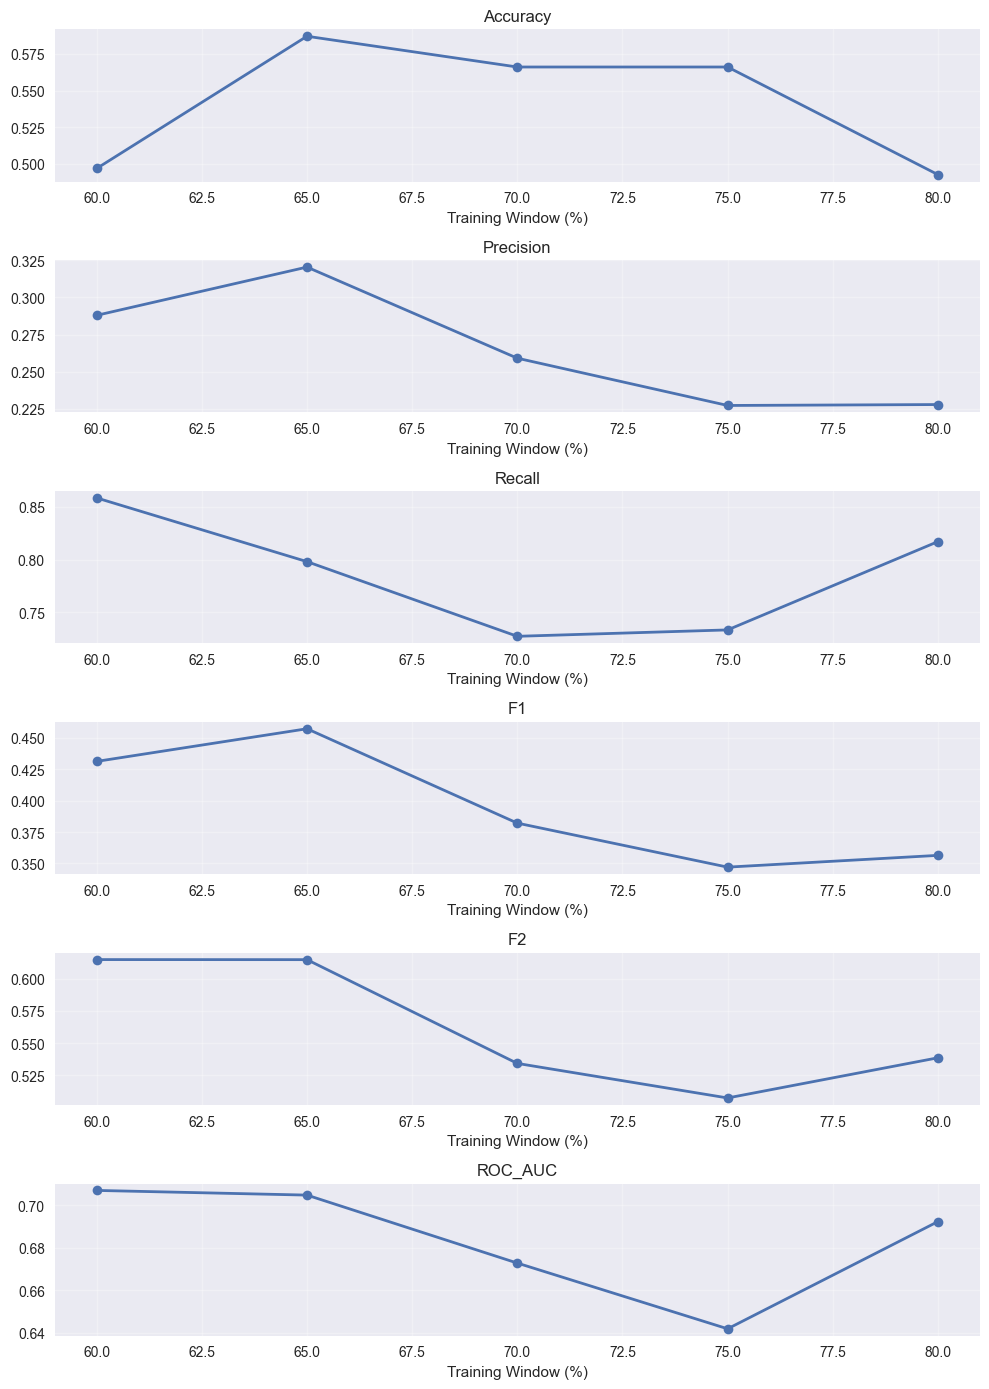

In [71]:
# ============================================================================
# WALK-FORWARD PERFORMANCE
# ============================================================================

metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'F2',
    'ROC_AUC'
]

fig, axes = plt.subplots(
    len(metrics),
    1,
    figsize=(10, 14)
)

for ax, metric in zip(axes, metrics):

    ax.plot(
        wf_results['Train_%'],
        wf_results[metric],
        marker='o',
        linewidth=2
    )

    ax.set_title(metric)
    ax.set_xlabel('Training Window (%)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()